# Mayo Clinic PBC Trial Survival Analysis

**Course:** PUBH 6854 Applied Computing in Health Data Science  
**Lab:** Lab 2 – Analysis Notebook

## Research Question

Among randomized participants in the Mayo Clinic PBC trial, was there evidence of a difference in survival between the D-penicillamine and placebo treatment groups?

## Data Source

This analysis uses data from the Mayo Clinic randomized trial in primary biliary cirrhosis (PBC), available through the `survival` R package and the Rdatasets repository.

The dataset includes baseline clinical and laboratory measurements, treatment assignment, follow-up time, and survival status. The randomized portion of the study compared D-penicillamine with placebo.

For this analysis, we restrict the study population to randomized participants with known treatment assignments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

*AI usage: I used ChatGPT for coding support with the Python implementation, particularly for setting up the environment and configuring the `lifelines` package, as I had limited prior experience using Python for survival analysis.*

In [2]:
url = "https://vincentarelbundock.github.io/Rdatasets/csv/survival/pbc.csv"

pbc = pd.read_csv(url)

In [3]:
pbc.head()

,rownames,id,time,status,trt,age,sex,ascites,hepato,spiders,...,bili,chol,albumin,copper,alk.phos,ast,trig,platelet,protime,stage
0,1,1,400,2,1.0,58.765229,f,1.0,1.0,1.0,...,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,2,2,4500,0,1.0,56.446270,f,0.0,1.0,1.0,...,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,3,3,1012,2,1.0,70.072553,m,0.0,0.0,0.0,...,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,4,4,1925,2,1.0,54.740589,f,0.0,1.0,1.0,...,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,5,5,1504,1,2.0,38.105407,f,0.0,1.0,1.0,...,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0


## Data Inspection

Before conducting the analysis, we inspect the dataset dimensions, variables, and treatment assignments. The treatment variable (`trt`) is coded as 1 for D-penicillamine and 2 for placebo. Participants without a randomized treatment assignment have missing values for `trt`.

In [4]:
pbc.shape

(418, 21)

In [5]:
pbc.columns.tolist()

['rownames',
 'id',
 'time',
 'status',
 'trt',
 'age',
 'sex',
 'ascites',
 'hepato',
 'spiders',
 'edema',
 'bili',
 'chol',
 'albumin',
 'copper',
 'alk.phos',
 'ast',
 'trig',
 'platelet',
 'protime',
 'stage']

In [6]:
pbc["trt"].value_counts(dropna=False) 

trt
1.0    158
2.0    154
NaN    106
Name: count, dtype: int64

In [7]:
pbc["status"].value_counts().sort_index()

status
0    232
1     25
2    161
Name: count, dtype: int64

## Outcome Definition

The outcome of interest is time to death. Follow-up time (`time`) is measured in days.

Death (`status = 2`) is treated as the event of interest. Participants who were alive at the end of follow-up (`status = 0`) are censored. Participants who underwent liver transplantation (`status = 1`) are censored at the time of transplantation.

Therefore, a binary event indicator is created as:

- `event = 1`: death
- `event = 0`: censored or liver transplantation

In [8]:
pbc_randomized = pbc[pbc["trt"].notna()].copy()

In [9]:
pbc_randomized["treatment"] = pbc_randomized["trt"].map({
    1: "D-penicillamine",
    2: "Placebo"
})

In [10]:
pbc_randomized["event"] = (pbc_randomized["status"] == 2).astype(int)

In [11]:
# check the derived outcome variable
pd.crosstab(
    pbc_randomized["status"],
    pbc_randomized["event"]
)

event,0,1
status,,
0,168,0
1,19,0
2,0,125


In [12]:
# check labeled group names
pbc_randomized["treatment"].value_counts()

treatment
D-penicillamine    158
Placebo            154
Name: count, dtype: int64

In [13]:
# 312 participants in the randomized trials are included in the analysis
pbc_randomized.shape

(312, 23)

## Descriptive Summary

We first summarize the number of randomized participants, deaths, and follow-up time by treatment group before comparing the survival distributions.

In [14]:
summary = (
    pbc_randomized
    .groupby("treatment")
    .agg(
        n=("id", "count"),
        deaths=("event", "sum"),
        median_observed_time_days=("time", "median")
    )
)

summary

,n,deaths,median_observed_time_days
treatment,,,
D-penicillamine,158,65,1895.0
Placebo,154,60,1811.0


In [15]:
# check missing values
pbc_randomized[["time", "event", "treatment"]].isna().sum()

time         0
event        0
treatment    0
dtype: int64

## Kaplan–Meier Survival Analysis

Kaplan–Meier survival curves were estimated separately for the D-penicillamine and placebo groups. Death was treated as the event of interest, while participants who underwent liver transplantation or remained alive at the end of follow-up were censored.

In [16]:
pen_mask = pbc_randomized["treatment"] == "D-penicillamine"
placebo_mask = pbc_randomized["treatment"] == "Placebo"

In [17]:
kmf_pen = KaplanMeierFitter()
kmf_placebo = KaplanMeierFitter()

kmf_pen.fit(
    pbc_randomized.loc[pen_mask, "time"],
    event_observed=pbc_randomized.loc[pen_mask, "event"],
    label="D-penicillamine"
)

kmf_placebo.fit(
    pbc_randomized.loc[placebo_mask, "time"],
    event_observed=pbc_randomized.loc[placebo_mask, "event"],
    label="Placebo"
);

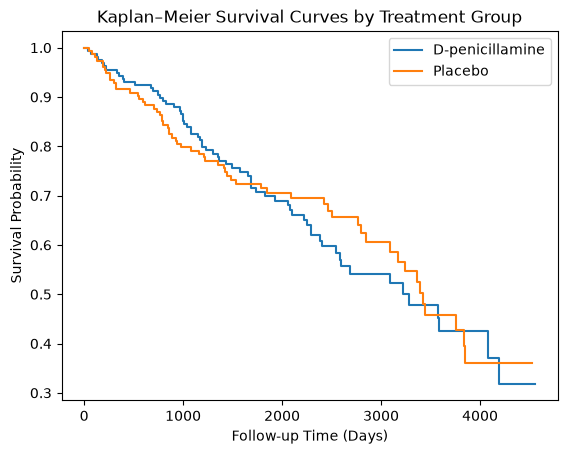

In [18]:
ax = kmf_pen.plot_survival_function(ci_show=False)
kmf_placebo.plot_survival_function(ax=ax, ci_show=False)

plt.xlabel("Follow-up Time (Days)")
plt.ylabel("Survival Probability")
plt.title("Kaplan–Meier Survival Curves by Treatment Group")
plt.show()

## Log-Rank Test

A log-rank test was used to formally compare the survival distributions between the D-penicillamine and placebo groups.

In [19]:
logrank_result = logrank_test(
    pbc_randomized.loc[pen_mask, "time"],
    pbc_randomized.loc[placebo_mask, "time"],
    event_observed_A=pbc_randomized.loc[pen_mask, "event"],
    event_observed_B=pbc_randomized.loc[placebo_mask, "event"]
)

logrank_result.print_summary()

## Interpretation

The Kaplan-Meier curves for the D-penicillamine and placebo groups were generally similar over the follow-up period. The curves crossed at several points, and neither treatment group showed a consistently higher survival probability than the other.

Using a significance level of α = 0.05, the log-rank test did not show a statistically significant difference in survival between the two treatment groups (p = 0.75). Since the p-value was greater than 0.05, we failed to reject the null hypothesis of equal survival distributions.

Overall, this unadjusted analysis did not provide evidence of a difference in survival between participants assigned to D-penicillamine and those assigned to placebo.

## Python vs. R Comparison

For this analysis, R was faster for me to write and was also the implementation I felt more confident using. I have more experience using R for statistical analyses, including survival analysis, so the workflow using `Surv()`, `survfit()`, and `survdiff()` was relatively direct and familiar. In contrast, the Python implementation required me to set up an appropriate environment and install the `lifelines` package before performing the survival analysis. I also needed to manage the Python environment carefully so that the analysis could be reproduced.

I have slightly more confidence in the R implementation because of my greater familiarity with R and the well-established `survival` package. However, the Python and R implementations produced essentially the same Kaplan–Meier curves and log-rank test result (p = 0.75). The agreement between the two independent implementations increases my confidence in the overall analysis and suggests that the results were not dependent on the choice of software.